# Analyze solar capacity factor vs LCOE components

This notebook analyzes the relationship between `solar_capacity_factor` and:

1. `LCOE_solar_$perMWh` (solar portion only)
2. `LCOE_batt_$perMWh` (battery portion only)

It merges site-level optimization outputs with facility attributes from `views/facility_master_v6.csv`.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve repo root from common working directories
_here = Path.cwd().resolve()
if _here.name == "notebooks":
    REPO = _here.parent.parent
elif _here.name == "flatblock_optimization":
    REPO = _here.parent
else:
    REPO = _here

OUT_DIR = REPO / "flatblock_optimization" / "outputs"
COMBINED = OUT_DIR / "combined_results_all_sites_v1.csv"
FACILITY_MASTER = REPO / "views" / "facility_master_v6.csv"

print("Repo:", REPO)
print("Combined path:", COMBINED)
print("Facility master path:", FACILITY_MASTER)

Repo: /Users/annayuen/Desktop/industrial_facility_db
Combined path: /Users/annayuen/Desktop/industrial_facility_db/flatblock_optimization/outputs/combined_results_all_sites_v1.csv
Facility master path: /Users/annayuen/Desktop/industrial_facility_db/views/facility_master_v6.csv


In [2]:
def load_flatblock_results(repo_root: Path) -> pd.DataFrame:
    """
    Load site-level optimization results.
    Priority:
      1) flatblock_optimization/outputs/combined_results_all_sites_v1.csv
      2) concat of summary_site*.csv found under flatblock_optimization/scenarios
    """
    combined = repo_root / "flatblock_optimization" / "outputs" / "combined_results_all_sites_v1.csv"
    if combined.exists():
        df = pd.read_csv(combined)
        if "site" not in df.columns and "source_id" in df.columns:
            df["site"] = df["source_id"]
        return df

    scenarios_root = repo_root / "flatblock_optimization" / "scenarios"
    summary_paths = sorted(scenarios_root.rglob("summary_site*.csv"))
    if not summary_paths:
        raise FileNotFoundError(
            "No combined results CSV and no summary_site*.csv files were found. "
            "Generate optimization outputs first."
        )

    parts = []
    pat = re.compile(r"summary_site(\d+)\.csv$")
    for p in summary_paths:
        m = pat.search(p.name)
        if not m:
            continue
        site = int(m.group(1))
        one = pd.read_csv(p)
        if one.empty:
            continue
        row = one.iloc[[0]].copy()
        row["site"] = site
        parts.append(row)

    if not parts:
        raise ValueError("Found summary_site files, but none produced usable rows.")

    return pd.concat(parts, ignore_index=True)


res = load_flatblock_results(REPO)
fm = pd.read_csv(FACILITY_MASTER, usecols=["source_id", "solar_capacity_factor", "iso3_country", "sector", "source_type"])

res["source_id"] = pd.to_numeric(res["site"], errors="coerce")
df = res.merge(fm, on="source_id", how="left")

print(f"Loaded results rows: {len(res):,}")
print(f"Merged rows: {len(df):,}")
df.head(3)

Loaded results rows: 43,721
Merged rows: 43,749


,site,load_MW,S_opt_MW,Battery_capacity_MW,Battery_energy_MWh,LCOE_total_$perMWh,LCOE_solar_$perMWh,LCOE_batt_$perMWh,LCOE_unserved_$perMWh,Reliability_%,...,lat,lon,sector_x,source_type_x,capacity,capacity_units,source_type_y,iso3_country_y,sector_y,solar_capacity_factor
0,25454443,100,529.592506,236.458341,1418.750045,74.544310,27.283513,47.260797,0.0,90.0,...,27.3454,82.3165,power,coal,90.0,MW,coal,IND,power,0.209135
1,25454888,100,560.527334,237.884047,1427.304283,76.422964,28.877212,47.545752,0.0,90.0,...,17.9415,83.2232,power,coal,84.0,MW,coal,IND,power,0.196403
2,4406831,100,590.029661,238.110411,1428.662465,77.988106,30.397111,47.590995,0.0,90.0,...,16.8622,74.1984,power,biomass,44.0,MW,biomass,IND,power,0.197165


In [4]:
required_cols = ["solar_capacity_factor", "LCOE_solar_$perMWh", "LCOE_batt_$perMWh"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

for c in required_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Merge can produce suffixes when both sides carry similar columns.
# Coalesce to canonical names expected by analysis.
def coalesce_first(frame: pd.DataFrame, candidates: list[str], fallback=np.nan):
    present = [c for c in candidates if c in frame.columns]
    if not present:
        return pd.Series(fallback, index=frame.index)
    out = frame[present[0]].copy()
    for c in present[1:]:
        out = out.where(out.notna(), frame[c])
    return out

if "iso3_country" not in df.columns:
    df["iso3_country"] = coalesce_first(df, ["iso3_country_x", "iso3_country_y"])
if "sector" not in df.columns:
    df["sector"] = coalesce_first(df, ["sector_x", "sector_y"])
if "source_type" not in df.columns:
    df["source_type"] = coalesce_first(df, ["source_type_x", "source_type_y"])

analysis_cols = [
    "source_id", "iso3_country", "sector", "source_type",
    "solar_capacity_factor", "LCOE_solar_$perMWh", "LCOE_batt_$perMWh"
]
ana = df[analysis_cols].copy()

print("Columns available for context:", [c for c in ["iso3_country", "sector", "source_type"] if c in ana.columns])
ana.describe()

Columns available for context: ['iso3_country', 'sector', 'source_type']


,source_id,solar_capacity_factor,LCOE_solar_$perMWh,LCOE_batt_$perMWh
count,4.374900e+04,43749.000000,43749.000000,43749.000000
mean,3.140025e+07,0.190906,66.052567,56.645888
std,1.358904e+07,0.027753,78.097902,127.494572
min,1.100000e+02,0.091569,11.064699,14.013761
25%,2.545609e+07,0.175739,40.412831,37.315792
50%,3.847610e+07,0.190840,56.590748,46.828770
75%,3.848750e+07,0.207689,75.819656,58.659013
max,4.830644e+07,0.322023,6896.682736,5219.146447


## A) Solar capacity factor vs Solar LCOE

Higher `solar_capacity_factor` is expected to correlate with lower `LCOE_solar_$perMWh`.

Rows used (solar CF vs solar LCOE): 43,749
Pearson corr:  -0.2661
Spearman corr: -0.3338


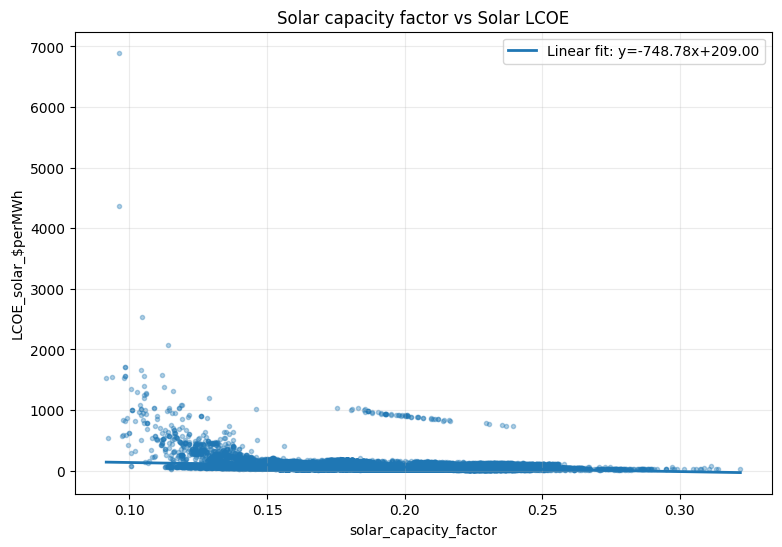

In [7]:
a = ana[["solar_capacity_factor", "LCOE_solar_$perMWh"]].dropna().copy()
print(f"Rows used (solar CF vs solar LCOE): {len(a):,}")

pearson_a = a["solar_capacity_factor"].corr(a["LCOE_solar_$perMWh"], method="pearson")
spearman_a = a["solar_capacity_factor"].corr(a["LCOE_solar_$perMWh"], method="spearman")
print(f"Pearson corr:  {pearson_a:.4f}")
print(f"Spearman corr: {spearman_a:.4f}")

x = a["solar_capacity_factor"].to_numpy()
y = a["LCOE_solar_$perMWh"].to_numpy()
m, b = np.polyfit(x, y, 1)
xx = np.linspace(np.nanmin(x), np.nanmax(x), 200)
yy = m * xx + b

plt.figure(figsize=(9, 6))
plt.scatter(x, y, s=9, alpha=0.35)
plt.plot(xx, yy, linewidth=2, label=f"Linear fit: y={m:.2f}x+{b:.2f}")
plt.xlabel("solar_capacity_factor")
plt.ylabel("LCOE_solar_$perMWh")
plt.title("Solar capacity factor vs Solar LCOE")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

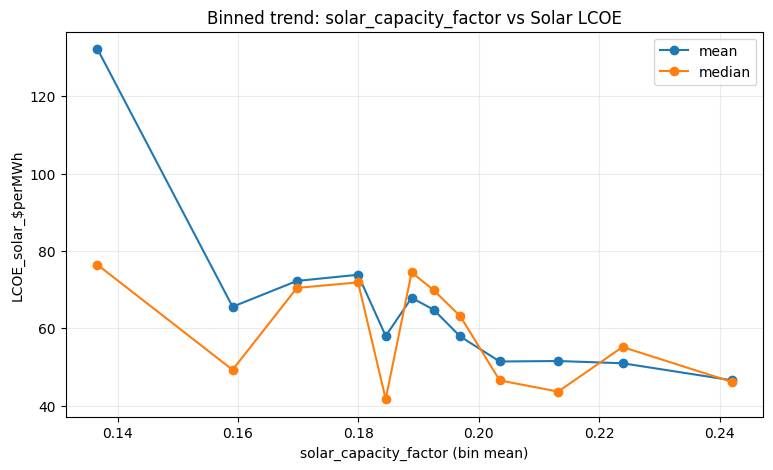

,n,cf_mid,lcoe_solar_mean,lcoe_solar_p50
0,3646,0.136659,132.182864,76.389238
1,3646,0.159101,65.547273,49.235204
2,3646,0.169789,72.218935,70.418729
3,3645,0.179951,73.825861,71.845138
4,3646,0.184539,57.986678,41.668745
5,3646,0.188845,67.857733,74.446052
6,3645,0.192506,64.779003,69.825671
7,3646,0.196921,57.855579,63.113937
8,3646,0.203481,51.391627,46.494561
9,3645,0.213189,51.510651,43.606964


In [8]:
bin_count = 12
a2 = a.copy()
a2["cf_bin"] = pd.qcut(a2["solar_capacity_factor"], q=bin_count, duplicates="drop")
trend_a = (
    a2.groupby("cf_bin", observed=True)
      .agg(
          n=("LCOE_solar_$perMWh", "size"),
          cf_mid=("solar_capacity_factor", "mean"),
          lcoe_solar_mean=("LCOE_solar_$perMWh", "mean"),
          lcoe_solar_p50=("LCOE_solar_$perMWh", "median"),
      )
      .reset_index(drop=True)
)

plt.figure(figsize=(9, 5))
plt.plot(trend_a["cf_mid"], trend_a["lcoe_solar_mean"], marker="o", label="mean")
plt.plot(trend_a["cf_mid"], trend_a["lcoe_solar_p50"], marker="o", label="median")
plt.xlabel("solar_capacity_factor (bin mean)")
plt.ylabel("LCOE_solar_$perMWh")
plt.title("Binned trend: solar_capacity_factor vs Solar LCOE")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

trend_a

## B) Solar capacity factor vs Battery LCOE

Battery LCOE may still vary with solar profile quality, but the relationship can differ from the direct solar-cost relationship.

Rows used (solar CF vs battery LCOE): 43,749
Pearson corr:  -0.1354
Spearman corr: -0.2502


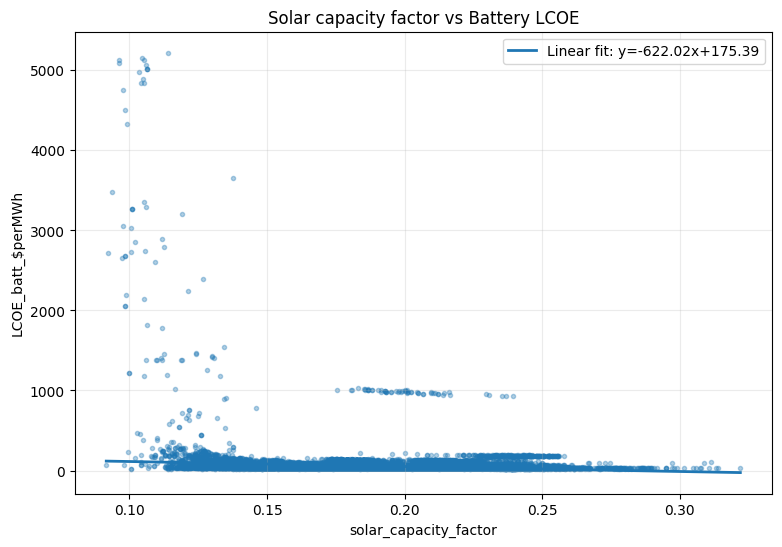

In [9]:
bdf = ana[["solar_capacity_factor", "LCOE_batt_$perMWh"]].dropna().copy()
print(f"Rows used (solar CF vs battery LCOE): {len(bdf):,}")

pearson_b = bdf["solar_capacity_factor"].corr(bdf["LCOE_batt_$perMWh"], method="pearson")
spearman_b = bdf["solar_capacity_factor"].corr(bdf["LCOE_batt_$perMWh"], method="spearman")
print(f"Pearson corr:  {pearson_b:.4f}")
print(f"Spearman corr: {spearman_b:.4f}")

x = bdf["solar_capacity_factor"].to_numpy()
y = bdf["LCOE_batt_$perMWh"].to_numpy()
m, b = np.polyfit(x, y, 1)
xx = np.linspace(np.nanmin(x), np.nanmax(x), 200)
yy = m * xx + b

plt.figure(figsize=(9, 6))
plt.scatter(x, y, s=9, alpha=0.35)
plt.plot(xx, yy, linewidth=2, label=f"Linear fit: y={m:.2f}x+{b:.2f}")
plt.xlabel("solar_capacity_factor")
plt.ylabel("LCOE_batt_$perMWh")
plt.title("Solar capacity factor vs Battery LCOE")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

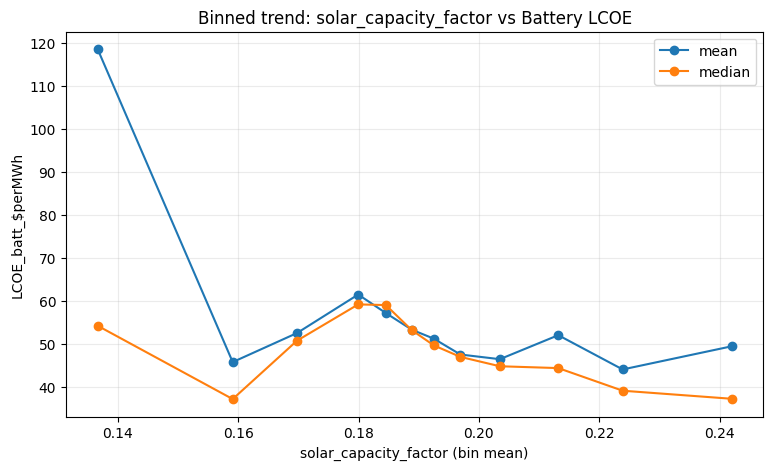

,n,cf_mid,lcoe_batt_mean,lcoe_batt_p50
0,3646,0.136659,118.496006,54.242381
1,3646,0.159101,45.801058,37.209715
2,3646,0.169789,52.548769,50.776745
3,3645,0.179951,61.488790,59.198232
4,3646,0.184539,57.195885,59.047092
5,3646,0.188845,53.326438,53.224440
6,3645,0.192506,51.243583,49.689166
7,3646,0.196921,47.562101,47.009341
8,3646,0.203481,46.475012,44.833180
9,3645,0.213189,52.049597,44.407801


In [10]:
bin_count = 12
b2 = bdf.copy()
b2["cf_bin"] = pd.qcut(b2["solar_capacity_factor"], q=bin_count, duplicates="drop")
trend_b = (
    b2.groupby("cf_bin", observed=True)
      .agg(
          n=("LCOE_batt_$perMWh", "size"),
          cf_mid=("solar_capacity_factor", "mean"),
          lcoe_batt_mean=("LCOE_batt_$perMWh", "mean"),
          lcoe_batt_p50=("LCOE_batt_$perMWh", "median"),
      )
      .reset_index(drop=True)
)

plt.figure(figsize=(9, 5))
plt.plot(trend_b["cf_mid"], trend_b["lcoe_batt_mean"], marker="o", label="mean")
plt.plot(trend_b["cf_mid"], trend_b["lcoe_batt_p50"], marker="o", label="median")
plt.xlabel("solar_capacity_factor (bin mean)")
plt.ylabel("LCOE_batt_$perMWh")
plt.title("Binned trend: solar_capacity_factor vs Battery LCOE")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

trend_b

In [11]:
summary = pd.DataFrame(
    [
        {
            "analysis": "solar_capacity_factor vs LCOE_solar_$perMWh",
            "rows": len(a),
            "pearson": pearson_a,
            "spearman": spearman_a,
        },
        {
            "analysis": "solar_capacity_factor vs LCOE_batt_$perMWh",
            "rows": len(bdf),
            "pearson": pearson_b,
            "spearman": spearman_b,
        },
    ]
)
summary

,analysis,rows,pearson,spearman
0,solar_capacity_factor vs LCOE_solar_$perMWh,43749,-0.266090,-0.333830
1,solar_capacity_factor vs LCOE_batt_$perMWh,43749,-0.135402,-0.250185
